<a href="https://colab.research.google.com/github/Jo-ohnny/CI345_ML/blob/main/Homework2_By_Jean.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [71]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

## homework 2 for Video data

## Date : 5/18/2026

Name : Jean Oussou



# Step 1: Loading and Analyze Data

In [72]:
from google.colab import drive
import pandas as pd

#Mount Google Drive
drive.mount('/content/drive')

# Path to your CSV in Drive
diabetes_store_file = '/content/drive/MyDrive/CI345_ML/data/diabetes_prediction_dataset.csv'

orginal_dtable = pd.read_csv(diabetes_store_file)
orginal_dtable.head(3)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0


In [73]:
df = orginal_dtable.copy()
print(df.shape)

(100000, 9)


In [74]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB


In [75]:
df.dtypes

,0
gender,object
age,float64
hypertension,int64
heart_disease,int64
smoking_history,object
bmi,float64
HbA1c_level,float64
blood_glucose_level,int64
diabetes,int64


In [76]:
#5) Show missing data (hint: use df.isnull().sum()
df.isnull().sum()

,0
gender,0
age,0
hypertension,0
heart_disease,0
smoking_history,0
bmi,0
HbA1c_level,0
blood_glucose_level,0
diabetes,0


In [77]:
#Show descriptive statistics of age and bmi (Use .describe() )
df[['age','bmi']].describe()

,age,bmi
count,100000.000000,100000.000000
mean,41.885856,27.320767
std,22.516840,6.636783
min,0.080000,10.010000
25%,24.000000,23.630000
50%,43.000000,27.320000
75%,60.000000,29.580000
max,80.000000,95.690000


In [78]:
#Show mean, std, min, max of age and bmi (Use min, max, std, meanfunction)
df[['age','bmi']].agg(['min','max','std','mean'])

,age,bmi
min,0.080000,10.010000
max,80.000000,95.690000
std,22.516840,6.636783
mean,41.885856,27.320767


#Step 3: Data Visualization: show following chart

<Axes: ylabel='count'>

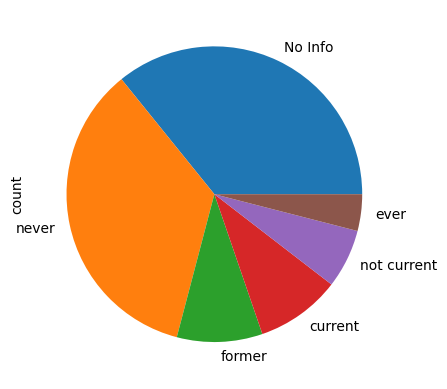

In [79]:
#1) Create Pie chart for Smoke History
df['smoking_history'].value_counts().plot(kind='pie')

<Axes: xlabel='smoking_history'>

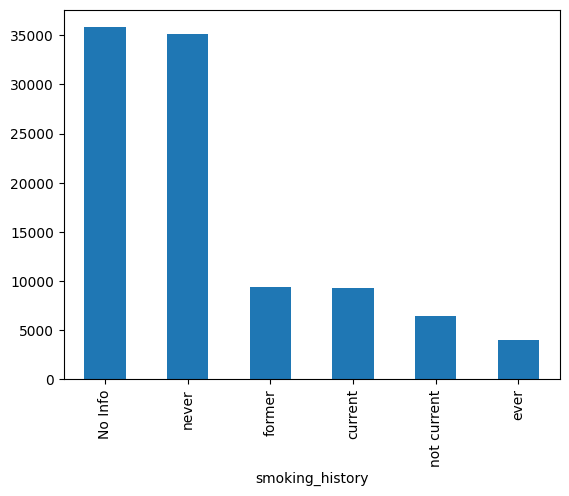

In [80]:
#2) Bar chart for Smoke History
df['smoking_history'].value_counts().plot(kind='bar')

<Axes: title={'center': 'BMI Distribution'}, ylabel='Frequency'>

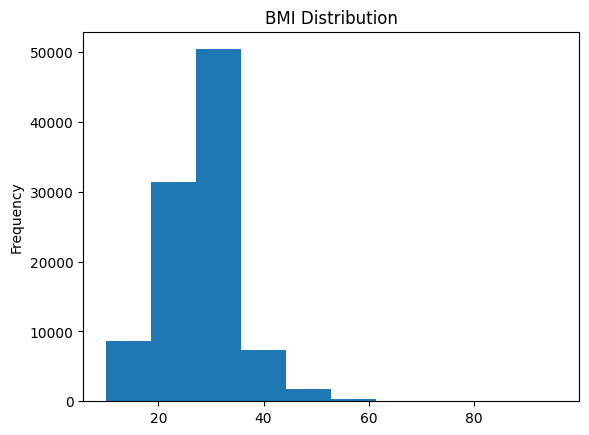

In [81]:
#Histogram chart (Show all bmi)
df['bmi'].plot(
    kind='hist',
    title='BMI Distribution'
)

<Axes: title={'center': 'BMI Distribution'}, ylabel='Frequency'>

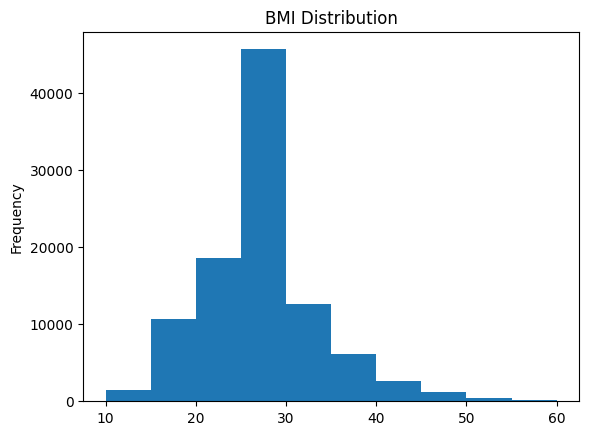

In [82]:
#Histogram chart for Smoke History (Show  bmi < 60 )
df[df['bmi'] < 60]['bmi'].plot(
    kind='hist',
    title='BMI Distribution'
)

<Axes: xlabel='age', ylabel='bmi'>

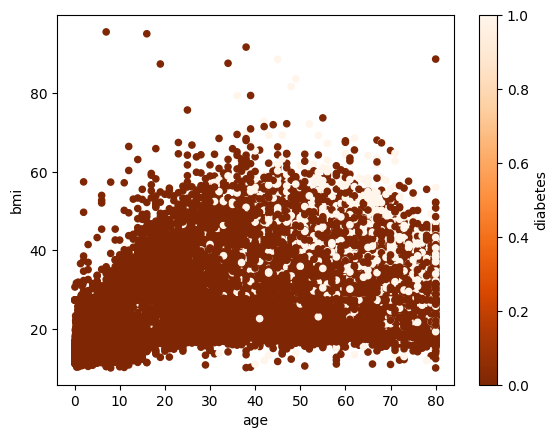

In [83]:
#Charts by your choice( Suggestion: charts show the correlations of age, bmi to diabetes)
df.plot.scatter(x='age', y='bmi', c='diabetes', colormap='Oranges_r')
#df.plot.scatter(x='age', y='bmi', color='blue')

<Axes: xlabel='diabetes'>

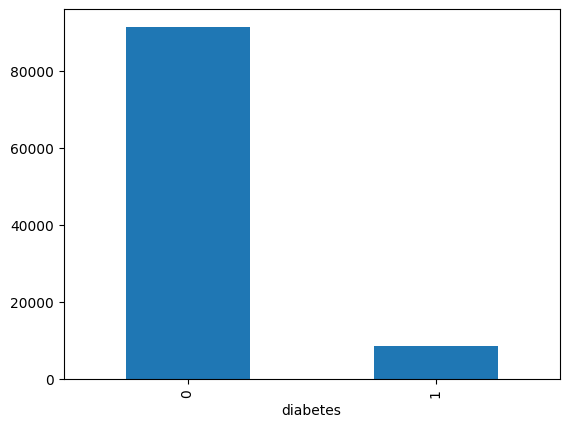

In [84]:
#Target Data
df['diabetes'].value_counts().plot(kind='bar')

#Step 4: Data Processing

Convert categorical features to numerical feature

Method 1 : Using LabelEncoder for gender


In [85]:
print(df.gender.dtypes)
df.head(3)

object


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0


In [86]:
#Method 2: Using mapping for Smoking_history
print(df.head(2))
hist_mapping = {'never': 0, 'No Info': 1, 'former': 2, 'current': 3, 'not current': 4, 'ever': 5}
#Applying mapping and get new columns
df['smoking_history'] = df['smoking_history'].map(hist_mapping)
df.head(3)

   gender   age  hypertension  heart_disease smoking_history    bmi  \
0  Female  80.0             0              1           never  25.19   
1  Female  54.0             0              0         No Info  27.32   

   HbA1c_level  blood_glucose_level  diabetes  
0          6.6                  140         0  
1          6.6                   80         0  


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,0,25.19,6.6,140,0
1,Female,54.0,0,0,1,27.32,6.6,80,0
2,Male,28.0,0,0,0,27.32,5.7,158,0


#Method 3: Using dummies
##Df_us_dummies


In [87]:
# Only converting categoric features to numerical feature
# Method 3 : Using get_dummies -
category_cols = ['gender', 'smoking_history']

df_use_dummies = pd.get_dummies(df, columns=category_cols, dtype=int)
print('---------')
print(df_use_dummies.dtypes)
df_use_dummies.head(2)

---------
age                    float64
hypertension             int64
heart_disease            int64
bmi                    float64
HbA1c_level            float64
blood_glucose_level      int64
diabetes                 int64
gender_Female            int64
gender_Male              int64
gender_Other             int64
smoking_history_0        int64
smoking_history_1        int64
smoking_history_2        int64
smoking_history_3        int64
smoking_history_4        int64
smoking_history_5        int64
dtype: object


,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes,gender_Female,gender_Male,gender_Other,smoking_history_0,smoking_history_1,smoking_history_2,smoking_history_3,smoking_history_4,smoking_history_5
0,80.0,0,1,25.19,6.6,140,0,1,0,0,1,0,0,0,0,0
1,54.0,0,0,27.32,6.6,80,0,1,0,0,0,1,0,0,0,0


In [88]:
# Mehtod 4. Preprocessing: OneHot for categorical + MinMax scaling for numeric
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder()
encoded = ohe.fit_transform(df[['gender']])
encoded_df = pd.DataFrame(encoded.toarray(), columns=ohe.get_feature_names_out(['gender']))

#Step 5: Separate Data feature and target

In [89]:
# Current process data has not category
print(df.columns)

# Make a copy to avoid SettingWithCopyWarning when modifying 'df'
processed_df = df.copy()

# Handle 'gender' column: Apply one-hot encoding
processed_df = pd.get_dummies(processed_df, columns=['gender'], dtype=int)

# Handle 'smoking_history' column: Fill NaN values
# Assuming 0 is an appropriate fill for this context; consider other imputation for larger datasets.
processed_df['smoking_history'] = processed_df['smoking_history'].fillna(0)

# The original `cols_used` excluded 'bmi' and included original 'gender' and 'smoking_history'.
# Now, 'gender' is replaced by 'gender_Female' and 'gender_Male'.
# 'smoking_history' is numerical (filled NaNs).
final_data_cols = [
    'age', 'hypertension', 'heart_disease', 'smoking_history', 'HbA1c_level', 'blood_glucose_level',
    'gender_Female', 'gender_Male'
]

# Separate data part
data = processed_df[final_data_cols]

# Get target
target = processed_df['diabetes']

print(data.shape)
print(target.shape)
print(target.head(2))
data.head(3)

Index(['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history',
       'bmi', 'HbA1c_level', 'blood_glucose_level', 'diabetes'],
      dtype='object')
(100000, 8)
(100000,)
0    0
1    0
Name: diabetes, dtype: int64


,age,hypertension,heart_disease,smoking_history,HbA1c_level,blood_glucose_level,gender_Female,gender_Male
0,80.0,0,1,0,6.6,140,1,0
1,54.0,0,0,1,6.6,80,1,0
2,28.0,0,0,0,5.7,158,0,1


#Step 6: Training three classifiers (40)
##	Separate training and testing dataset
##	Create three classifiers
##	Apply testing data
##	Evaluation Report
##	Confusion Matrix


#1)	Using KNN Classifier: (Try at least three k numbers, hint: use loop)

In [90]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

# Split data
X_train, X_test, y_train, y_test = train_test_split(data, target, test_size=0.2, random_state=42)

# Try different k values
k_values = [3, 5, 7]

for k in k_values:
    print("K =", k)
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)

    # Evaluation
    print(confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred))
    print("--------------------------------------------------")

K = 3
[[18121   171]
 [  744   964]]
              precision    recall  f1-score   support

           0       0.96      0.99      0.98     18292
           1       0.85      0.56      0.68      1708

    accuracy                           0.95     20000
   macro avg       0.90      0.78      0.83     20000
weighted avg       0.95      0.95      0.95     20000

--------------------------------------------------
K = 5
[[18201    91]
 [  770   938]]
              precision    recall  f1-score   support

           0       0.96      1.00      0.98     18292
           1       0.91      0.55      0.69      1708

    accuracy                           0.96     20000
   macro avg       0.94      0.77      0.83     20000
weighted avg       0.96      0.96      0.95     20000

--------------------------------------------------
K = 7
[[18244    48]
 [  790   918]]
              precision    recall  f1-score   support

           0       0.96      1.00      0.98     18292
           1       0.95 

#2)	Using Decision Tree

In [91]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

# Split data
X_train, X_test, y_train, y_test = train_test_split(data, target, test_size=0.2, random_state=42)

# Create Decision Tree model
dt = DecisionTreeClassifier()

# Train
dt.fit(X_train, y_train)

# Predict
y_pred = dt.predict(X_test)

# Evaluation
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test,  y_pred))

[[17890   402]
 [  453  1255]]
              precision    recall  f1-score   support

           0       0.98      0.98      0.98     18292
           1       0.76      0.73      0.75      1708

    accuracy                           0.96     20000
   macro avg       0.87      0.86      0.86     20000
weighted avg       0.96      0.96      0.96     20000



In [92]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

# Split data
X_train, X_test, y_train, y_test = train_test_split(data, target, test_size=0.2, random_state=42)

# Create Logistic Regression model
log_reg = LogisticRegression(max_iter=1000)

# Train
log_reg.fit(X_train, y_train)

# Predict
y_pred = log_reg.predict(X_test)

# Evaluation
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[18133   159]
 [  697  1011]]
              precision    recall  f1-score   support

           0       0.96      0.99      0.98     18292
           1       0.86      0.59      0.70      1708

    accuracy                           0.96     20000
   macro avg       0.91      0.79      0.84     20000
weighted avg       0.95      0.96      0.95     20000



In [93]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, classification_report

nb = GaussianNB()
nb.fit(X_train, y_train)
y_pred = nb.predict(X_test)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[17071  1221]
 [  646  1062]]
              precision    recall  f1-score   support

           0       0.96      0.93      0.95     18292
           1       0.47      0.62      0.53      1708

    accuracy                           0.91     20000
   macro avg       0.71      0.78      0.74     20000
weighted avg       0.92      0.91      0.91     20000

